# TRABAJO MATRIZ DE CONFUSIÓN

1) id: identificador único
2) gender: "Hombre", "Mujer" u "Otro"
3) age: edad del paciente
4) hypertension: 0 si el paciente no tiene hipertensión, 1 si el paciente tiene hipertensión
5) heart_disease: 0 si el paciente no tiene ninguna enfermedad cardíaca, 1 si el paciente tiene una enfermedad cardíaca
6) ever_casado: "No" o "Sí"
7) work_type: "niños", "Govt_jov", "Never_worked", "Privado" o "Autónomo"
8) Residence_type: "Rural" o "Urban"
9) avg_glucose_nivel: nivel promedio de glucosa en sangre
10) bmi: índice de masa corporal
11) smoking_status: "anteriormente fumado", "nunca fumado", "humo" o "Desconocido"*
12) stroke: 1 si el paciente tuvo un accidente cerebrovascular o 0 si no
*Nota: "Desconocido" en smoking_status significa que la información no está disponible para este paciente

### LIBRERIAS 

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, r2_score, mean_squared_error, roc_curve, roc_auc_score, ConfusionMatrixDisplay, f1_score, precision_score, recall_score

## 1. Carga de datos

In [31]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

## 2. Exploración inicial

In [32]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [33]:
df = df.drop(columns=["id"])

In [34]:
df.shape

(5110, 11)

In [35]:
df['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [36]:
df.corr(numeric_only=True)['stroke'].abs().sort_values(ascending=False)[1:]

age                  0.245257
heart_disease        0.134914
avg_glucose_level    0.131945
hypertension         0.127904
bmi                  0.042374
Name: stroke, dtype: float64

In [37]:
df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


## 3. Limpieza de los datos

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


In [39]:
df.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [40]:
df.dropna(inplace=True)

In [41]:
df.isna().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [42]:
df.shape

(4909, 11)

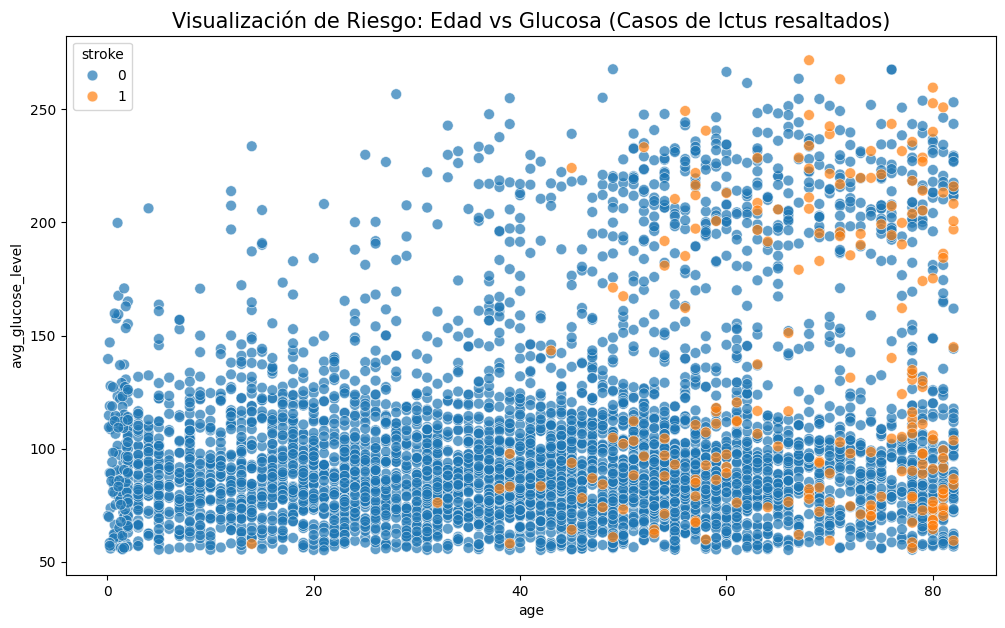

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ordenamos para que los casos de stroke=1 se dibujen al final (encima de los demás)
df_plot = df.sort_values(by='stroke')

plt.figure(figsize=(12, 7))

# 2. Usamos 's' para aumentar el tamaño de los puntos y 'edgecolor' para que no se mezclen
sns.scatterplot(data=df_plot, x='age', y='avg_glucose_level', 
                hue='stroke', palette=['#1f77b4', '#ff7f0e'], 
                alpha=0.7, s=60, edgecolor='w', linewidth=0.5)

plt.title('Visualización de Riesgo: Edad vs Glucosa (Casos de Ictus resaltados)', fontsize=15)
plt.show()

## 4. Selección de variables

In [44]:
df = pd.get_dummies(df,dtype=int)

In [45]:
df.corr(numeric_only=True)['stroke'].abs().sort_values(ascending=False)[1:]

age                               0.232331
hypertension                      0.142515
avg_glucose_level                 0.138936
heart_disease                     0.137938
ever_married_Yes                  0.105089
ever_married_No                   0.105089
work_type_children                0.080971
smoking_status_Unknown            0.075016
smoking_status_formerly smoked    0.057320
work_type_Self-employed           0.055356
bmi                               0.042374
smoking_status_smokes             0.021530
work_type_Private                 0.014934
work_type_Never_worked            0.014149
smoking_status_never smoked       0.010723
gender_Male                       0.006939
gender_Female                     0.006851
Residence_type_Rural              0.006031
Residence_type_Urban              0.006031
work_type_Govt_job                0.003553
gender_Other                      0.003010
Name: stroke, dtype: float64

In [46]:
df.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other,ever_married_No,...,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,0,1,0,0,...,0,1,0,0,0,1,0,1,0,0
2,80.0,0,1,105.92,32.5,1,0,1,0,0,...,0,1,0,0,1,0,0,0,1,0
3,49.0,0,0,171.23,34.4,1,1,0,0,0,...,0,1,0,0,0,1,0,0,0,1
4,79.0,1,0,174.12,24.0,1,1,0,0,0,...,0,0,1,0,1,0,0,0,1,0
5,81.0,0,0,186.21,29.0,1,0,1,0,0,...,0,1,0,0,0,1,0,1,0,0


In [47]:
df.shape

(4909, 22)

In [48]:
df['stroke'].value_counts()

stroke
0    4700
1     209
Name: count, dtype: int64

## 5. Definicion de X e y

In [49]:
X = df.drop(["stroke"],axis=1)
y = df["stroke"]

In [50]:
print(X.shape)
print(y.shape)

(4909, 21)
(4909,)


## 6. Escalado

In [51]:
# Guardamos el nombre de las variables para usarlo en el random forest
feature_names = df.drop("stroke", axis=1).columns

In [52]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [53]:
print("Primeros registros de X escalada:")
print(X[:5, :3])

Primeros registros de X escalada:
[[ 1.07013796 -0.31806673  4.38196829]
 [ 1.64656262 -0.31806673  4.38196829]
 [ 0.27201152 -0.31806673 -0.22820795]
 [ 1.60222226  3.14399438 -0.22820795]
 [ 1.69090297 -0.31806673 -0.22820795]]


## 7. Train/Test split

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify=y)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

X_train: (3927, 21)
X_test:  (982, 21)
y_train: (3927,)
y_test:  (982,)


## 8. Entrenamiento de modelos de clasificación

In [55]:

# valores_C = [0.1, 1, 5, 10, 50, 100]
# valores_gamma = [0.001, 0.01, 0.1, 1]
# valores_degree = [2, 3, 4, 5]
# valores_coef0 = [0, 0.5, 1, 2]

# # Funcion que recibe como parametro el tipo de kernel para entrenar el modelo con distintos hiperparametros almacenados en listas
# def mejor_eleccion(kernel):
#     mejor_acc = 0
#     mejor_config = None

#     for C in valores_C:

#         # LINEAR
#         if kernel == 'linear':
#             print(f"\nProbando LINEAR | C={C}")

#             svm = SVC(kernel='linear', C=C, random_state=42)

#             svm.fit(X_train, y_train)
#             pred = svm.predict(X_test)
#             acc = accuracy_score(y_test, pred)

#             print(f"Accuracy: {acc:.4f}")

#             if acc > mejor_acc:
#                 mejor_acc = acc
#                 mejor_config = ('linear', C)

#         # RBF
#         elif kernel == 'rbf':
#             for gamma in valores_gamma:
#                 print(f"\nProbando RBF | C={C} | gamma={gamma}")

#                 svm = SVC(kernel='rbf', C=C, gamma=gamma, random_state=42)

#                 svm.fit(X_train, y_train)
#                 pred = svm.predict(X_test)
#                 acc = accuracy_score(y_test, pred)

#                 print(f"Accuracy: {acc:.4f}")

#                 if acc > mejor_acc:
#                     mejor_acc = acc
#                     mejor_config = ('rbf', C, gamma)

#         # POLY 
#         elif kernel == 'poly':
#             for degree in valores_degree:
#                 for coef0 in valores_coef0:
#                     print(f"\nProbando POLY | C={C} | degree={degree} | coef0={coef0}")

#                     svm = SVC(kernel='poly', C=C, degree=degree, coef0=coef0, random_state=42)

#                     svm.fit(X_train, y_train)
#                     pred = svm.predict(X_test)
#                     acc = accuracy_score(y_test, pred)

#                     print(f"Accuracy: {acc:.4f}")

#                     if acc > mejor_acc:
#                         mejor_acc = acc
#                         mejor_config = ('poly', C, degree, coef0)

#     print(f"\nMejor Accuracy: {mejor_acc:.4f}")
#     print(f"Mejor configuración: {mejor_config}")


In [56]:
# mejor_eleccion("linear")

In [ ]:

svm_model = SVC(kernel='poly', C=10, degree=3, coef0=0, probability=True, class_weight='balanced')
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM Classification Report:\n", classification_report(y_test, y_pred_svm))
print("SVM Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

SVM Accuracy: 0.8197556008146639
SVM Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.84      0.90       940
           1       0.10      0.38      0.15        42

    accuracy                           0.82       982
   macro avg       0.53      0.61      0.53       982
weighted avg       0.93      0.82      0.87       982

SVM Confusion Matrix:
 [[789 151]
 [ 26  16]]


### LogisticRegression sin "class_weight='balanced'"

In [58]:
model_lr = LogisticRegression(max_iter=1000) 
model_lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [59]:
y_pred_lr = model_lr.predict(X_test)
print(accuracy_score(y_test, y_pred_lr))

0.9572301425661914


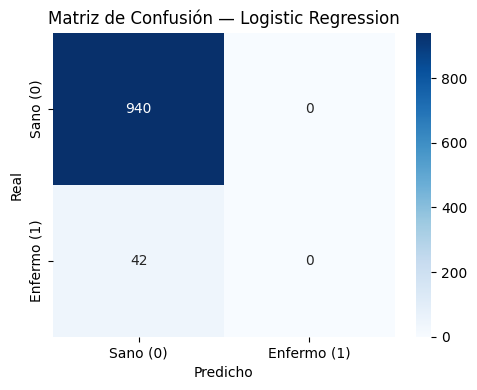

0.9572301425661914


In [60]:
#Calculamos las matrices numéricas
cm_lr = confusion_matrix(y_test, y_pred_lr)

#Visualización de la Matriz para Logistic Regression
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Sano (0)", "Enfermo (1)"],
            yticklabels=["Sano (0)", "Enfermo (1)"])
plt.title("Matriz de Confusión — Logistic Regression")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()
print(accuracy_score(y_test, y_pred_lr))

### LogisticRegression con "class_weight='balanced'"

In [61]:
model_lr_balanced = LogisticRegression(max_iter=1000, class_weight='balanced') 
model_lr_balanced.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [62]:
y_pred_lr_balanced = model_lr_balanced.predict(X_test)
print(accuracy_score(y_test, y_pred_lr_balanced))

0.7566191446028513


In [63]:
# Stratified K-Fold divide los datos en partes, cada una con proporciones similares de cada clase
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
X_skf = X
y_skf = y

for train_index, test_index in skf.split(X_skf, y_skf):
    X_train_skf, X_test_skf = X_skf[train_index], X_skf[test_index]
    y_train_skf, y_test_skf = y_skf.iloc[train_index], y_skf.iloc[test_index]

    model_lr_balanced.fit(X_train_skf, y_train_skf)
    y_pred_skf = model_lr_balanced.predict(X_test_skf)

    acc = accuracy_score(y_test_skf, y_pred_skf)
    scores.append(acc)

print("Accuracy por fold:", scores)
print("Accuracy media:", np.mean(scores))

Accuracy por fold: [0.745417515274949, 0.7688391038696538, 0.7372708757637475, 0.7087576374745418, 0.7553516819571865]
Accuracy media: 0.7431273628680157


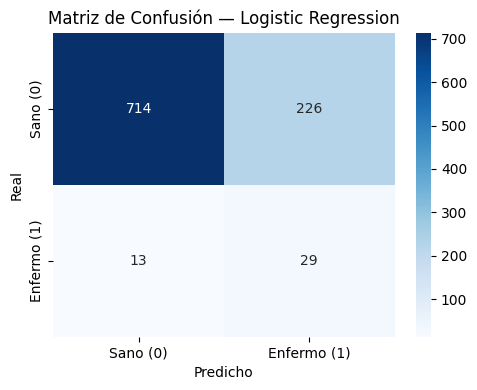

0.7566191446028513


In [64]:
#Calculamos las matrices numéricas
cm_lr = confusion_matrix(y_test, y_pred_lr_balanced)

#Visualización de la Matriz para Logistic Regression
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Sano (0)", "Enfermo (1)"],
            yticklabels=["Sano (0)", "Enfermo (1)"])
plt.title("Matriz de Confusión — Logistic Regression")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()
print(accuracy_score(y_test, y_pred_lr_balanced))

### RandomForestClassifier sin "class_weight='balanced'"

In [65]:
rf_clf = RandomForestClassifier(n_estimators=600, n_jobs=1, random_state=42)
rf_clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",600
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [66]:
y_pred_rf = rf_clf.predict(X_test)
print(accuracy_score(y_test, y_pred_rf))

0.9541751527494908


In [67]:
importances = pd.Series(rf_clf.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False)

for feature, importance in importances.items():
    print(f"{feature}: {importance:.4f}")

avg_glucose_level: 0.2630
age: 0.2321
bmi: 0.2259
hypertension: 0.0335
heart_disease: 0.0251
smoking_status_never smoked: 0.0207
Residence_type_Urban: 0.0206
work_type_Private: 0.0198
gender_Male: 0.0194
Residence_type_Rural: 0.0192
gender_Female: 0.0190
work_type_Self-employed: 0.0180
smoking_status_formerly smoked: 0.0178
smoking_status_smokes: 0.0171
smoking_status_Unknown: 0.0139
work_type_Govt_job: 0.0134
ever_married_Yes: 0.0104
ever_married_No: 0.0102
work_type_children: 0.0010
work_type_Never_worked: 0.0000
gender_Other: 0.0000


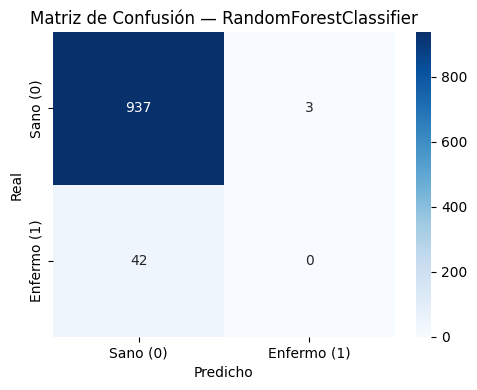

0.9541751527494908


In [68]:
#Calculamos las matrices numéricas
cm_lr = confusion_matrix(y_test, y_pred_rf)

#Visualización de la Matriz para Logistic Regression
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Sano (0)", "Enfermo (1)"],
            yticklabels=["Sano (0)", "Enfermo (1)"])
plt.title("Matriz de Confusión — RandomForestClassifier")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()
print(accuracy_score(y_test, y_pred_rf))

### RandomForestClassifier con "class_weight='balanced'"

In [ ]:
rf_clf_balanced = RandomForestClassifier(n_estimators=600, n_jobs=1, random_state=42, class_weight="balanced")
rf_clf_balanced.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",600
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [81]:
y_pred_rf_balanced = rf_clf_balanced.predict(X_test)
print(accuracy_score(y_test, y_pred_rf_balanced))

0.955193482688391


In [82]:
# Stratified K-Fold divide los datos en partes, cada una con proporciones similares de cada clase
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
X_skf = X
y_skf = y

for train_index, test_index in skf.split(X_skf, y_skf):
    X_train_skf, X_test_skf = X_skf[train_index], X_skf[test_index]
    y_train_skf, y_test_skf = y_skf.iloc[train_index], y_skf.iloc[test_index]

    rf_clf_balanced.fit(X_train_skf, y_train_skf)
    y_pred_skf = rf_clf_balanced.predict(X_test_skf)

    acc = accuracy_score(y_test_skf, y_pred_skf)
    scores.append(acc)

print("Accuracy por fold:", scores)
print("Accuracy media:", np.mean(scores))

Accuracy por fold: [0.9572301425661914, 0.9582484725050916, 0.9531568228105907, 0.9562118126272913, 0.9571865443425076]
Accuracy media: 0.9564067589703346


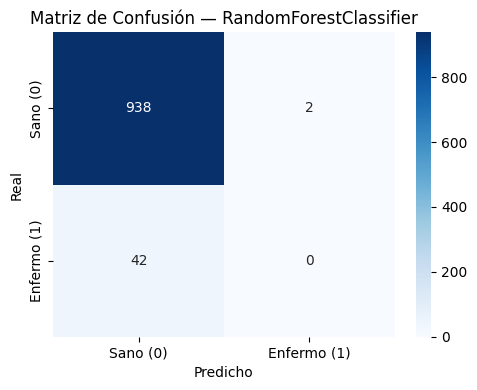

0.955193482688391


In [83]:
#Calculamos las matrices numéricas
cm_lr = confusion_matrix(y_test, y_pred_rf_balanced)

#Visualización de la Matriz para Logistic Regression
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Sano (0)", "Enfermo (1)"],
            yticklabels=["Sano (0)", "Enfermo (1)"])
plt.title("Matriz de Confusión — RandomForestClassifier")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()
print(accuracy_score(y_test, y_pred_rf_balanced))

### ACCURACY / F1-SCORE / PRECISION / RECALL / ROC-AUC

In [84]:
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, accuracy_score

# NOTA: Asegúrate de que al definir svm_model usaste probability=True
# svm_model = SVC(kernel='poly', probability=True)

models = {
    "Logistic Regression": model_lr,
    "Logistic Regression Balanced": model_lr_balanced,
    "Random Forest": rf_clf,
    "Random Forest Balanced": rf_clf_balanced,
    "SVM Poly": svm_model
}

# Usar una lista de diccionarios es más limpio para luego crear un DataFrame
results_list = []

for name, model in models.items():
    # Entrenamiento
    model.fit(X_train, y_train)
    
    # Predicciones
    y_pred = model.predict(X_test)
    
    # Manejo de probabilidades para ROC-AUC (Evita errores con SVM)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        # En caso de que el modelo no soporte probabilidades (como un SVC sin probability=True)
        # se usan los decision_function o se avisa del error
        y_prob = model.decision_function(X_test) 

    # Cálculo de métricas
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }
    
    results_list.append(metrics)

    # Print elegante
    print(f"\n--- {name} ---")
    for metric, value in metrics.items():
        if metric != "Model":
            print(f"{metric:10}: {value:.4f}")

# Bonus: Convertir a DataFrame para comparar fácilmente
df_results = pd.DataFrame(results_list)


--- Logistic Regression ---
Accuracy  : 0.9572
Precision : 0.0000
Recall    : 0.0000
F1-score  : 0.0000
ROC-AUC   : 0.8136

--- Logistic Regression Balanced ---
Accuracy  : 0.7566
Precision : 0.1137
Recall    : 0.6905
F1-score  : 0.1953
ROC-AUC   : 0.8104

--- Random Forest ---
Accuracy  : 0.9542
Precision : 0.0000
Recall    : 0.0000
F1-score  : 0.0000
ROC-AUC   : 0.7423

--- Random Forest Balanced ---
Accuracy  : 0.9552
Precision : 0.0000
Recall    : 0.0000
F1-score  : 0.0000
ROC-AUC   : 0.7461

--- SVM Poly ---
Accuracy  : 0.8198
Precision : 0.0958
Recall    : 0.3810
F1-score  : 0.1531
ROC-AUC   : 0.6652


In [85]:
# models = {
#     "Logistic Regression": model_lr,
#     "Logistic Regression Balanced": model_lr_balanced,
#     "Random Forest": rf_clf,
#     "Random Forest Balanced": rf_clf_balanced,
#     "SVM Poly": svm_model
# }

# f1_scores = []
# precision_scores = []
# recall_scores = []
# roc_auc_scores = []
# accuracy_scores = []

# for name, model in models.items():

#     model.fit(X_train, y_train)

#     y_pred = model.predict(X_test)

#     # probabilidades para ROC-AUC
#     y_prob = model.predict_proba(X_test)[:, 1]

#     f1 = f1_score(y_test, y_pred)
#     precision = precision_score(y_test, y_pred, zero_division=0)
#     recall = recall_score(y_test, y_pred, zero_division=0)
#     roc_auc = roc_auc_score(y_test, y_prob)
#     accuracy = accuracy_score(y_test, y_pred)

#     f1_scores.append(f1)
#     precision_scores.append(precision)
#     recall_scores.append(recall)
#     roc_auc_scores.append(roc_auc)
#     accuracy_scores.append(accuracy)

#     print(f"\n{name}")
#     print(f"Accuracy:    {accuracy:.4f}")
#     print(f"F1-score:    {f1:.4f}")
#     print(f"Precision:   {precision:.4f}")
#     print(f"Recall:      {recall:.4f}")
#     print(f"ROC-AUC:     {roc_auc:.4f}")